# 01 · Feature attribution on the Iris QNN

**Computes.** First-order feature Shapley values for a single-$R_Y$ QNN (Iris, *setosa* vs *versicolor*, $d=4$) against a dataset-mean baseline, by **Owen diagonal integration** of the exact multilinear extension versus **exact $2^4$ coalition enumeration**. The finite lift $\phi(x_i)=[1,\cos x_i,\sin x_i]$ makes the circuit output multilinear in the coalition coordinates, so Owen integration is *exact* once $M\ge\lceil d/2\rceil=2$; $M=1$ is not.

**Produces.** `figures/fig_feature_first.png` and `results/01.json` (Table 1 headline numbers).

**Seed.** Fixed: QNN seed 0, instance cohort seed 123. All values are reproducible and byte-stable.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))          # import the shared tnshapq package
import numpy as np
import matplotlib.pyplot as plt
import tnshapq as T
from tnshapq import datasets, exact, owen, metrics
from tnshapq.io_utils import save_results, savefig

SEED = 0
np.random.seed(SEED)
plt.rcParams.update({'font.size': 13, 'axes.titlesize': 13, 'axes.labelsize': 13,
                     'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11})
D = 4
M_EXACT = T.threshold_M(D, order=1)                # ceil(d/2) = 2
print("dimension d =", D, " exactness threshold M =", M_EXACT)

dimension d = 4  exactness threshold M = 2


In [2]:
# Trained single-R_Y QNN and a deterministic instance cohort
X, y, baseline, qnn, acc = datasets.iris_qnn(D)
cohort = datasets.pick_instances(X, 8, seed=123)
print(f"Iris d={D}: train acc = {acc:.3f}")
print(f"dataset-mean baseline = {np.round(baseline, 3)}")
print(f"cohort = {len(cohort)} instances (indices {[i for i,_ in cohort]})")

Iris d=4: train acc = 0.970
dataset-mean baseline = [1.363 1.439 1.426 1.268]
cohort = 8 instances (indices [1, 5, 18, 21, 25, 56, 64, 88])


In [3]:
# Exact enumeration vs Owen (M=2 exact, M=1 inexact) over the cohort
phi_exact, phi_M2, phi_M1 = [], [], []
for idx, x in cohort:
    tab = exact.feature_value_table(qnn, D, x, baseline)
    phi_exact.append(exact.exact_shapley(tab, D))
    phi_M2.append(owen.owen_integral_shapley(qnn, D, x, baseline, M_EXACT)[0])
    phi_M1.append(owen.owen_integral_shapley(qnn, D, x, baseline, 1)[0])
phi_exact = np.array(phi_exact); phi_M2 = np.array(phi_M2); phi_M1 = np.array(phi_M1)

evals = owen.owen_integral_shapley(qnn, D, cohort[0][1], baseline, M_EXACT)[1]
mae_M2 = metrics.mae(phi_M2, phi_exact)
mae_M1 = metrics.mae(phi_M1, phi_exact)
cos_M2 = float(np.mean([metrics.cosine(a, b) for a, b in zip(phi_M2, phi_exact)]))
print(f"Owen M={M_EXACT} (exact):   MAE = {mae_M2:.2e}   cosine = {cos_M2:.6f}   "
      f"evals/instance = {evals}  (vs {2**D} enumeration)")
print(f"Owen M=1 (inexact):  MAE = {mae_M1:.2e}   evals/instance = {2*D}")

Owen M=2 (exact):   MAE = 4.25e-17   cosine = 1.000000   evals/instance = 16  (vs 16 enumeration)
Owen M=1 (inexact):  MAE = 1.82e-04   evals/instance = 8


In [4]:
# Quadrature-order sweep: MAE collapses to machine precision exactly at M = ceil(d/2)
Ms = [1, 2, 3]
mae_by_M = np.array([
    metrics.mae(np.array([owen.owen_integral_shapley(qnn, D, x, baseline, M)[0]
                          for _, x in cohort]), phi_exact)
    for M in Ms])
for M, e in zip(Ms, mae_by_M):
    print(f"  M={M}: MAE = {e:.2e}")

  M=1: MAE = 1.82e-04
  M=2: MAE = 4.25e-17
  M=3: MAE = 6.45e-17


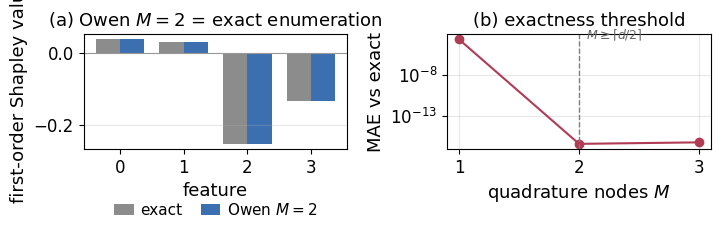

saved figures/fig_feature_first.png


In [5]:
# Figure: (a) exact vs Owen bars on a hero instance; (b) the exactness threshold
hero = 0
pe, po = phi_exact[hero], phi_M2[hero]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.4, 2.9))
xb = np.arange(D); wid = 0.38
a1.bar(xb - wid/2, pe, wid, color='0.55', label='exact')
a1.bar(xb + wid/2, po, wid, color='#3b6fb0', label=r'Owen $M{=}2$')
a1.axhline(0, color='0.6', lw=0.8); a1.set_xticks(xb)
a1.set_xlabel('feature'); a1.set_ylabel('first-order Shapley value')
a1.set_title('(a) Owen $M{=}2$ = exact enumeration')
a1.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.34), ncol=2, columnspacing=1.2, handlelength=1.3, handletextpad=0.4); a1.grid(alpha=0.3, axis='y')

a2.semilogy(Ms, np.clip(mae_by_M, 1e-18, None), 'o-', color='#b03b54')
a2.axvline(M_EXACT, color='0.5', ls='--', lw=1)
a2.text(M_EXACT + 0.06, mae_by_M[0], r'$M\geq\lceil d/2\rceil$', color='0.4', fontsize=9)
a2.set_xticks(Ms); a2.set_xlabel('quadrature nodes $M$')
a2.set_ylabel('MAE vs exact'); a2.set_title('(b) exactness threshold')
a2.grid(alpha=0.3, which='both')
fig.tight_layout()
savefig(fig, 'fig_feature_first.png')
plt.show()
print("saved figures/fig_feature_first.png")

In [6]:
# Table 1 — first-order feature attribution (hero instance) and headline JSON
print(f"Table 1 - first-order feature Shapley (hero instance {cohort[hero][0]})")
print(f"{'feature':>8} {'exact':>12} {'Owen M=2':>12} {'|diff|':>10}")
for i in range(D):
    print(f"{i:>8} {pe[i]:>12.6f} {po[i]:>12.6f} {abs(pe[i]-po[i]):>10.1e}")

res = {
    "task": "feature first-order Shapley (Iris d=4)",
    "d": D, "train_acc": acc, "M": int(M_EXACT), "threshold_M": int(M_EXACT),
    "evals": int(evals), "enum_evals": int(2**D), "cohort_size": len(cohort),
    "mae": mae_M2, "cosine": cos_M2, "mae_M1": mae_M1,
    "mae_by_M": {str(M): float(v) for M, v in zip(Ms, mae_by_M)},
    "threshold_ok": bool(mae_M2 < 1e-10 and mae_M1 > 1e-6),
    "phi_exact_hero": pe.tolist(), "phi_owen_hero": po.tolist(),
}
save_results("01", res)
print("saved results/01.json")

Table 1 - first-order feature Shapley (hero instance 1)
 feature        exact     Owen M=2     |diff|
       0     0.037242     0.037242    0.0e+00
       1     0.029455     0.029455    2.4e-17
       2    -0.251999    -0.251999    1.1e-16
       3    -0.132278    -0.132278    2.8e-17
saved results/01.json


In [7]:
# Verification: Owen M=2 matches 2^d enumeration to machine precision; M=1 does not
np.testing.assert_allclose(phi_M2, phi_exact, atol=1e-10, rtol=0)
assert mae_M1 > 1e-6, "M=1 must be inexact below the threshold"
print(f"PASS  Owen M={M_EXACT} reproduces 2^{D} enumeration: "
      f"MAE={mae_M2:.2e}, cosine={cos_M2:.6f}, cost={evals} evals vs {2**D}.")
print(f"      M=1 inexact (MAE={mae_M1:.2e}), confirming M>=ceil(d/2)={M_EXACT}.")

PASS  Owen M=2 reproduces 2^4 enumeration: MAE=4.25e-17, cosine=1.000000, cost=16 evals vs 16.
      M=1 inexact (MAE=1.82e-04), confirming M>=ceil(d/2)=2.
